In [1]:
# conda activate anndata

import os
import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [ ]:
corr_df = pd.read_csv(f"data/yao_2021_MOp_STAR_SyntheticDataset1_20pcntCells_25SD_200samples_SJ_pseudobulk_PSI_exon_corr.csv", index_col=0)

In [ ]:
ctypes = corr_df.columns[1:]
gene_names_df = corr_df['Gene']

### Prep PSI data

In [ ]:
# Load single-cell PSI data
sdata = ad.read_h5ad("data/yao_2021_MOp_STAR_SJ_counts_annotated_PSI.hd5")

In [5]:
sdata.shape

(5099, 12022)

In [ ]:
# Load cell metadata and latent space
adata = ad.read_h5ad("data/yao_2021_MOp_STAR_model/yao_2021_MOp_STAR_gene_counts_scVI.h5ad")

In [7]:
sum(adata.obs_names == sdata.obs_names)

5099

In [8]:
sc.pp.neighbors(adata, use_rep="scVI")
sc.tl.umap(adata, min_dist=0.2)

/mnt/lareaulab/reliscu/anaconda3/envs/anndata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


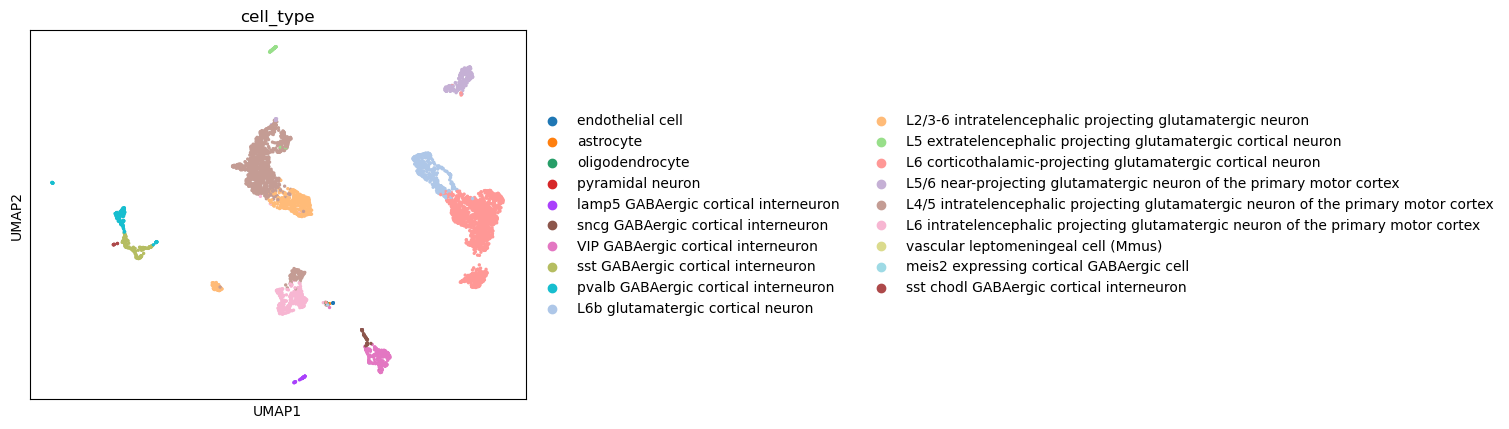

In [ ]:
sc.pl.umap(adata_temp, color="cell_type")

### Visualize at previously identified cell type exons

In [71]:
psi_df = pd.DataFrame(
    sdata.X, index=sdata.obs_names, columns=sdata.var_names
)

adata_temp = adata.copy()
adata_temp.obs = adata_temp.obs.join(psi_df)

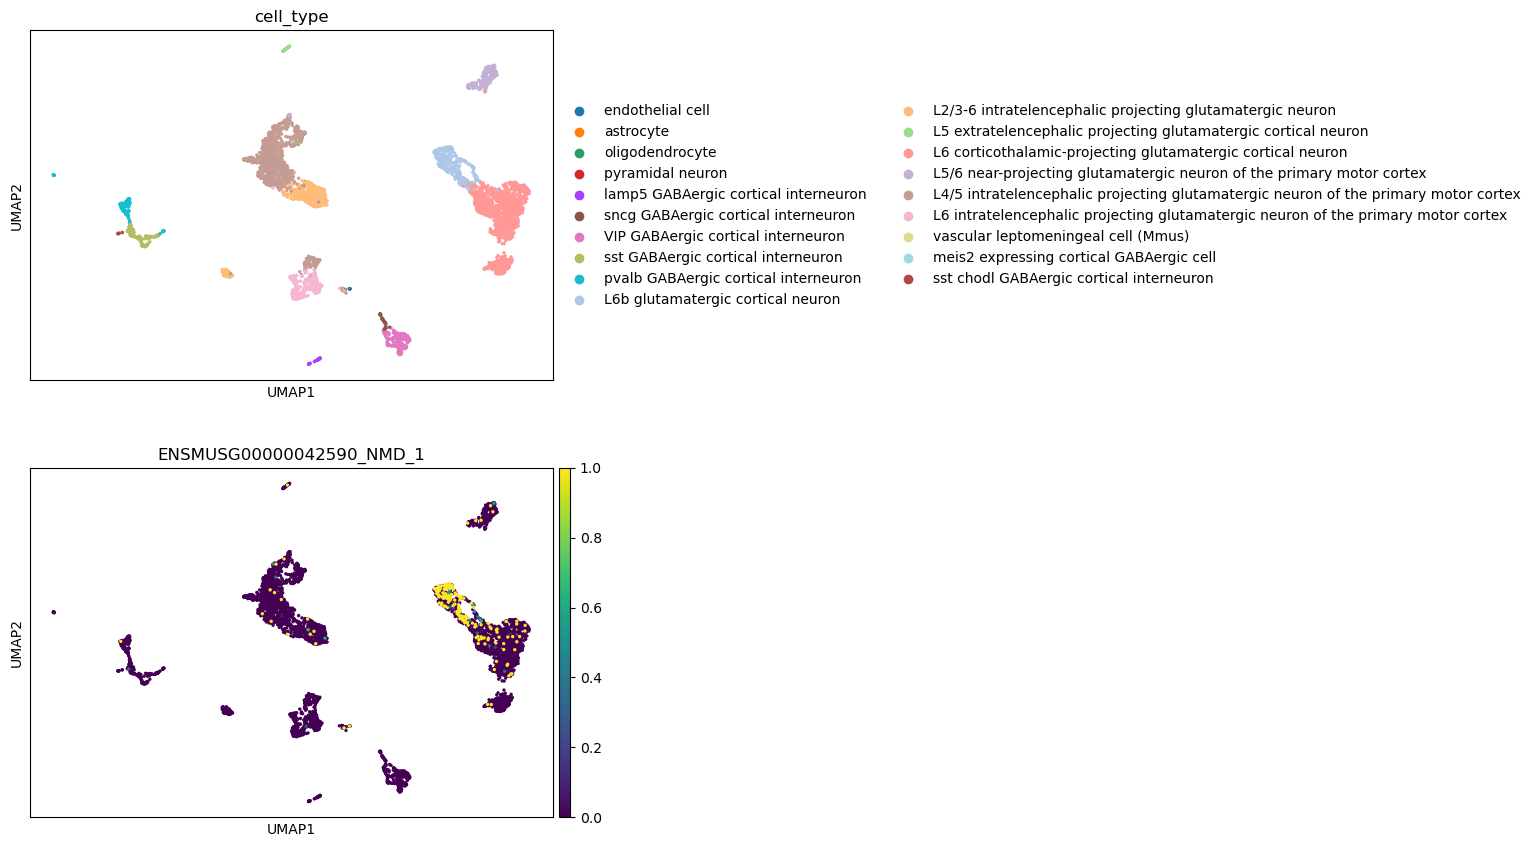

In [ ]:
# Ipo11 (2 exons detected)
# Cors: 0.789167223018318, 0.46043445816633
# Cell types: L6b glutamatergic cortical neuron, L6 corticothalamic-projecting glutamatergic cortical neuron

exon = "ENSMUSG00000042590_NMD_1"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           ncols=1)

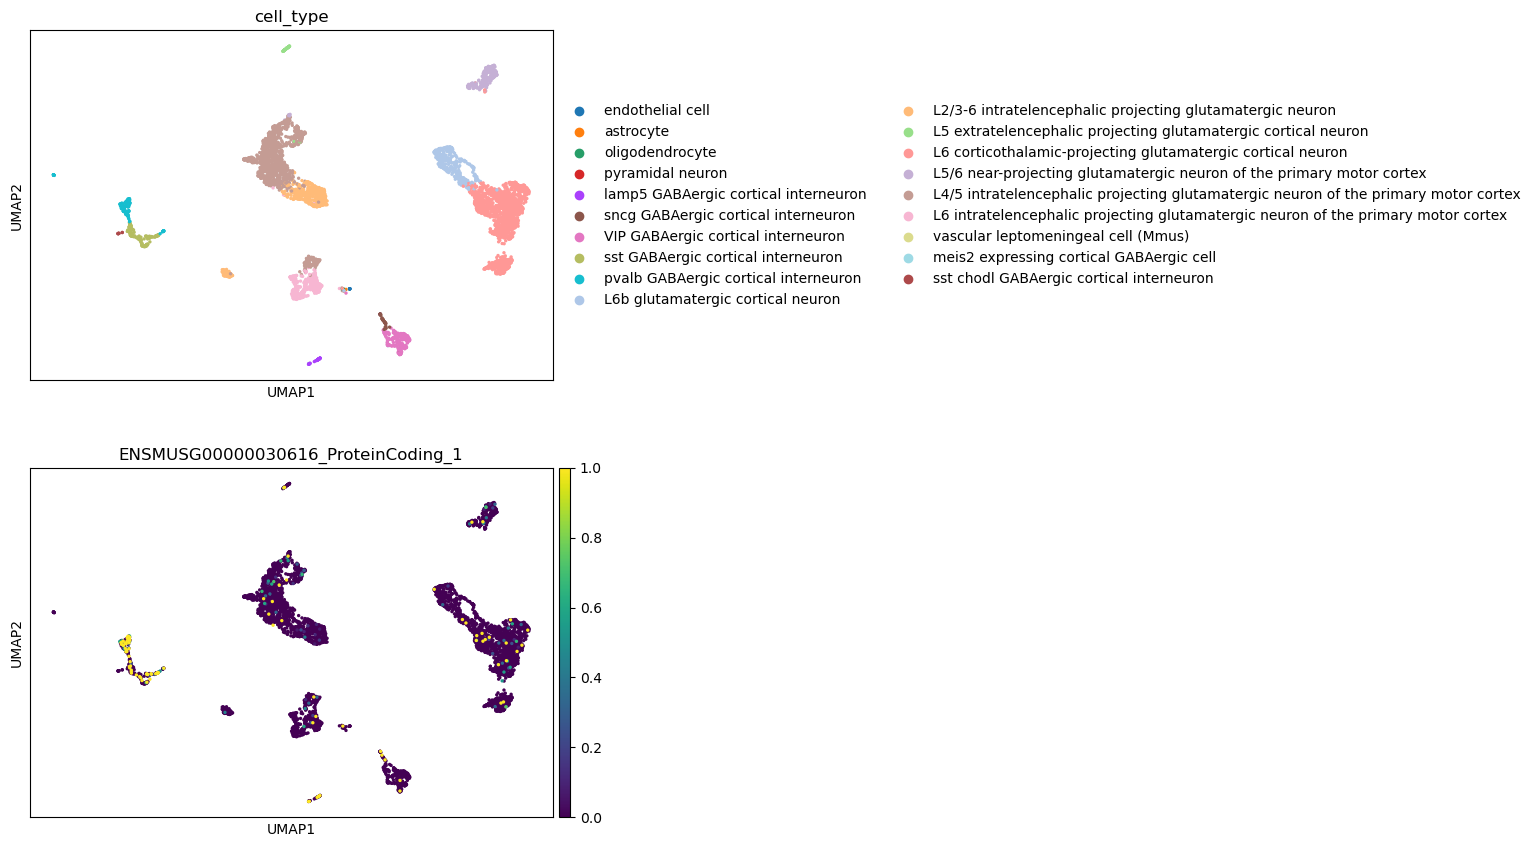

In [ ]:
# Sytl2

exon = "ENSMUSG00000030616_ProteinCoding_1"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           ncols=1)

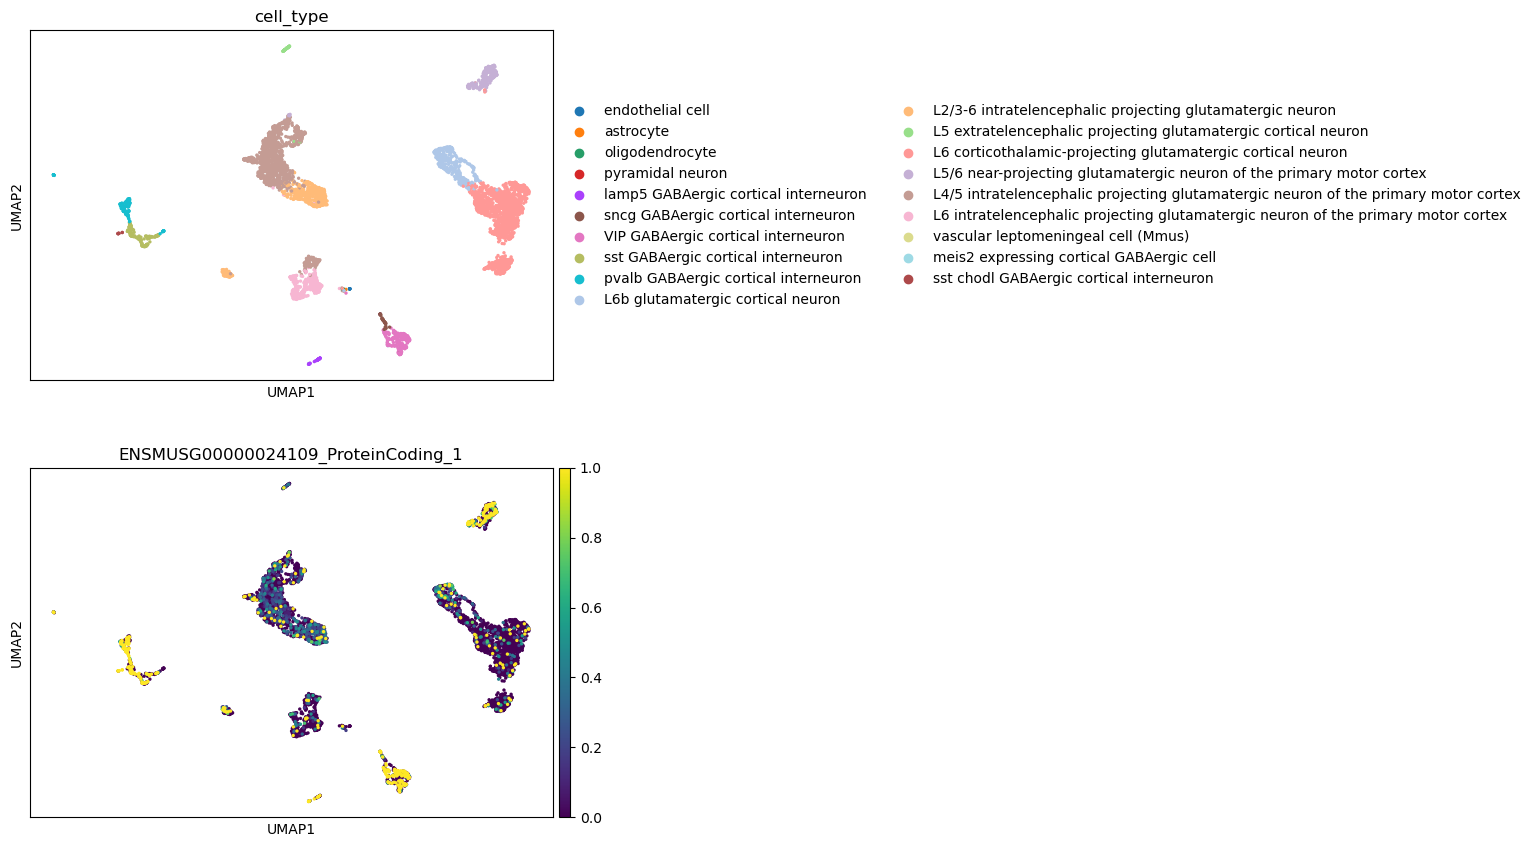

In [80]:
# Nrxn1 (5 exons detected)
# Cors: 0.61829769769037, 0.425207060075292, 0.349287893333654
# Cell types: vip GABAergic cortical interneuron, L5/6 near-projecting glutamatergic neuron of the primary motor cortex, pvalb GABAergic cortical interneturon

exon = "ENSMUSG00000024109_ProteinCoding_1"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           ncols=1)

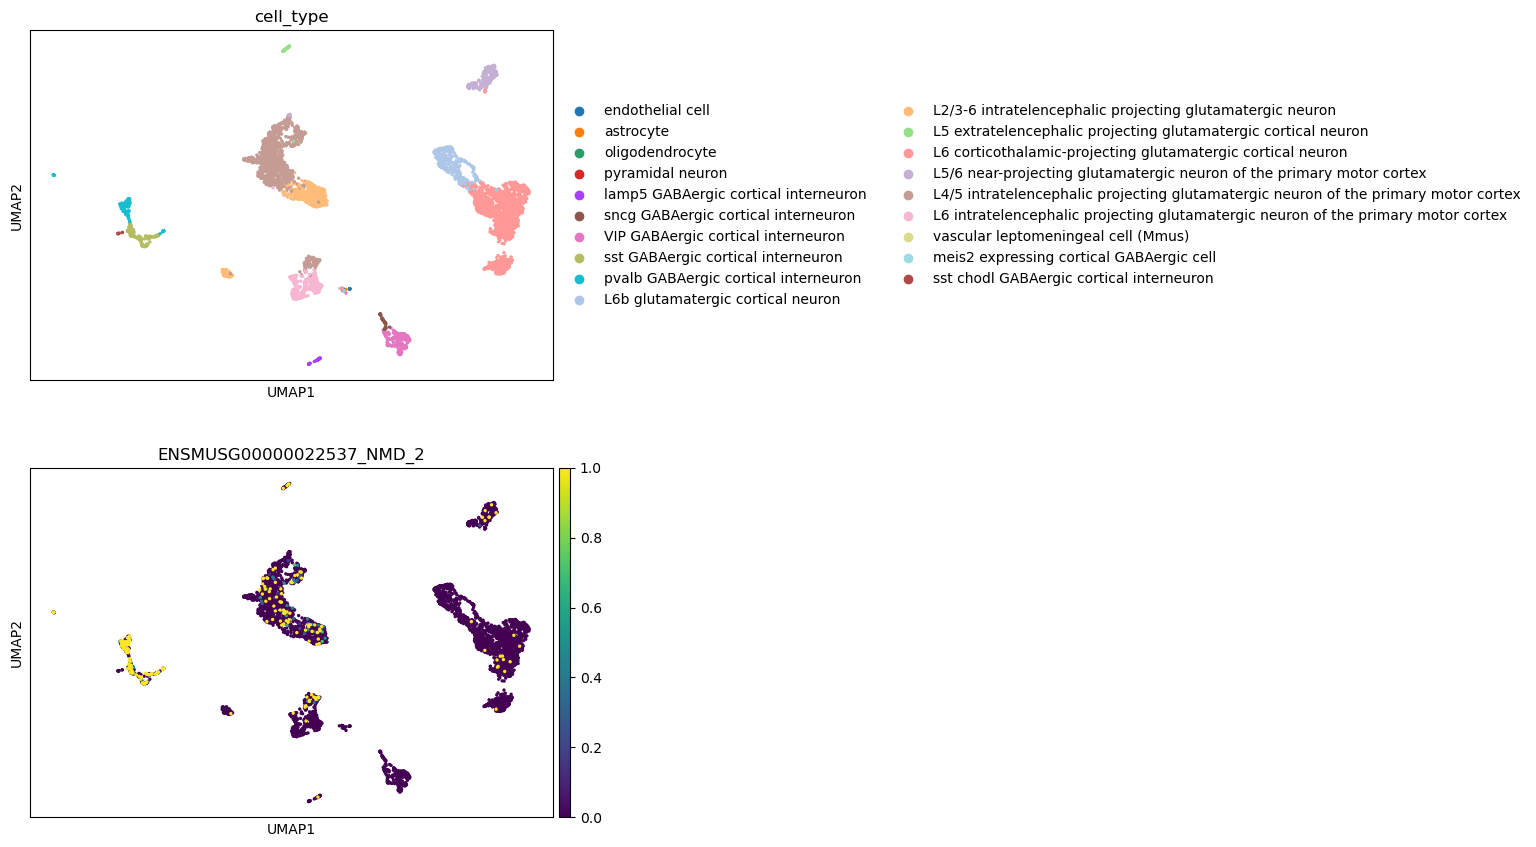

In [81]:
# Tmem44 (4 exons detected)
# Cors: 0.576198068473254, 0.439915817860295
# Cell types: sst GABAergic cortical interneuron, pvalb GABAergic cortical interneuron

exon = "ENSMUSG00000022537_NMD_2"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           ncols=1)

In [26]:
corr_df.loc[exon]

Gene                                                                                      Sytl2
endothelial_cell                                                                      -0.018129
oligodendrocyte                                                                        0.309178
pvalb_GABAergic_cortical_interneuron                                                   0.558853
L4_5_intratelencephalic_projecting_glutamatergic_neuron_of_the_primary_motor_cortex   -0.463771
L5_6_near-projecting_glutamatergic_neuron_of_the_primary_motor_cortex                  -0.06033
sst_chodl_GABAergic_cortical_interneuron                                               0.101832
L6_corticothalamic-projecting_glutamatergic_cortical_neuron                           -0.496953
VIP_GABAergic_cortical_interneuron                                                    -0.052782
lamp5_GABAergic_cortical_interneuron                                                   0.248561
sncg_GABAergic_cortical_interneuron     

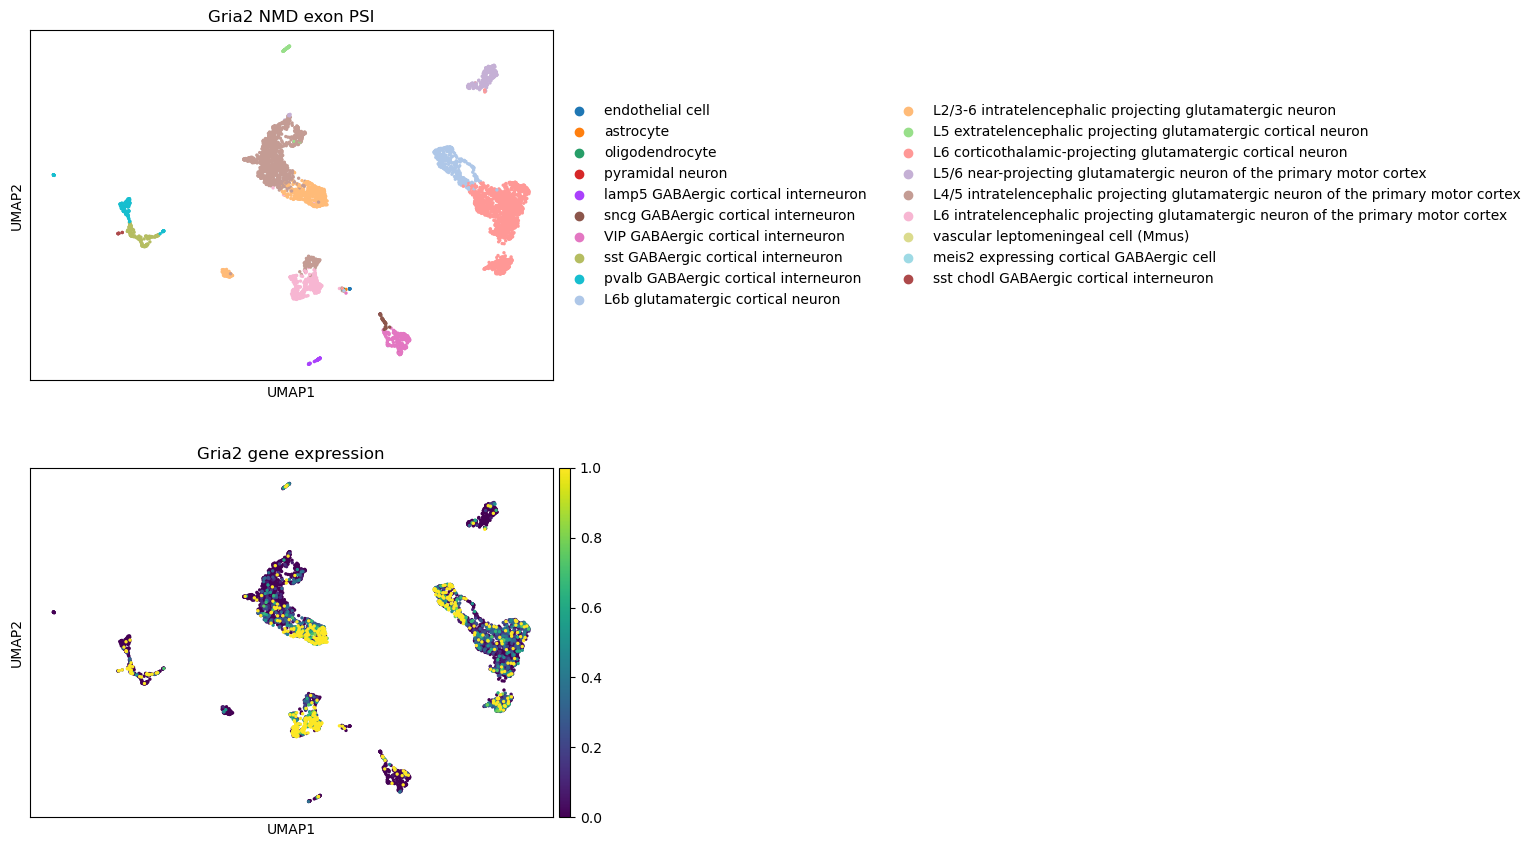

In [33]:
# Gria2 (2 exons detected)
# Cors: 0.652236089084128, 0.617346540889922
# Cell types: L6 intratelencephalic projecting glutamatergic neuron of the primary motor cortex, L2/3-6 intratelencephalic projecting glutamatergic neuron

exon = "ENSMUSG00000033981_NMD_1"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           title=['Gria2 NMD exon PSI', 'Gria2 gene expression'],
           ncols=1)

In [34]:
corr_df.loc[exon]

Gene                                                                                      Gria2
endothelial_cell                                                                      -0.103866
oligodendrocyte                                                                        0.134788
pvalb_GABAergic_cortical_interneuron                                                  -0.108854
L4_5_intratelencephalic_projecting_glutamatergic_neuron_of_the_primary_motor_cortex   -0.081638
L5_6_near-projecting_glutamatergic_neuron_of_the_primary_motor_cortex                 -0.339608
sst_chodl_GABAergic_cortical_interneuron                                                0.11552
L6_corticothalamic-projecting_glutamatergic_cortical_neuron                            0.117844
VIP_GABAergic_cortical_interneuron                                                    -0.106213
lamp5_GABAergic_cortical_interneuron                                                  -0.115045
sncg_GABAergic_cortical_interneuron     

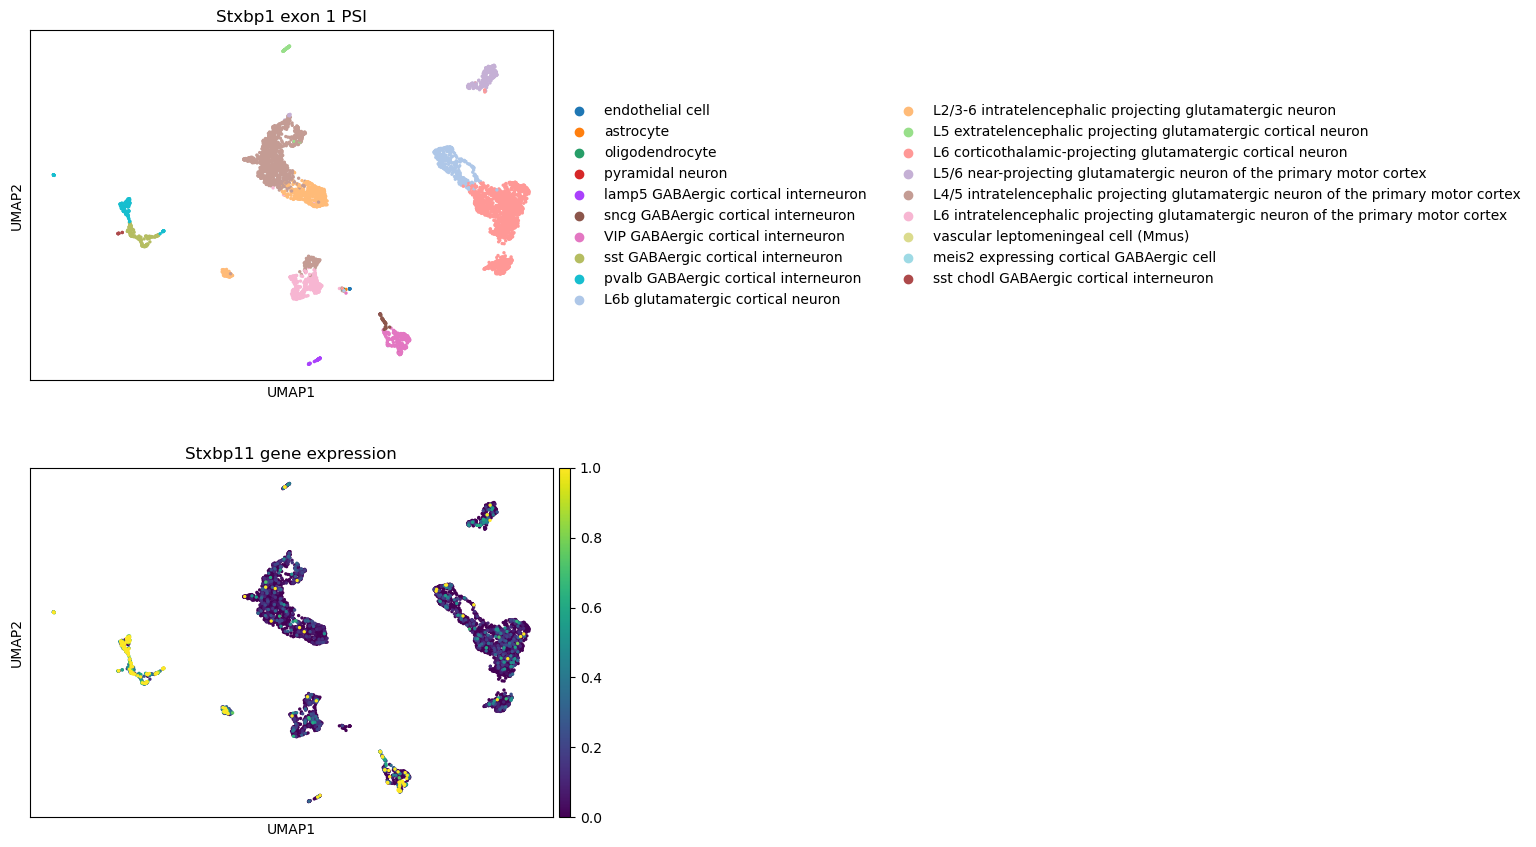

In [82]:
# Stxbp1 (1 exons detected)
# Cors: 0.744389529352848, 0.706060194824461 
# Cell types: pvalb GABAergic cortical interneuron, sst GABAergic cortical interneuron

exon = "ENSMUSG00000026797_ProteinCoding_1"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           title=['Stxbp1 exon 1 PSI', 'Stxbp11 gene expression'],
           ncols=1)

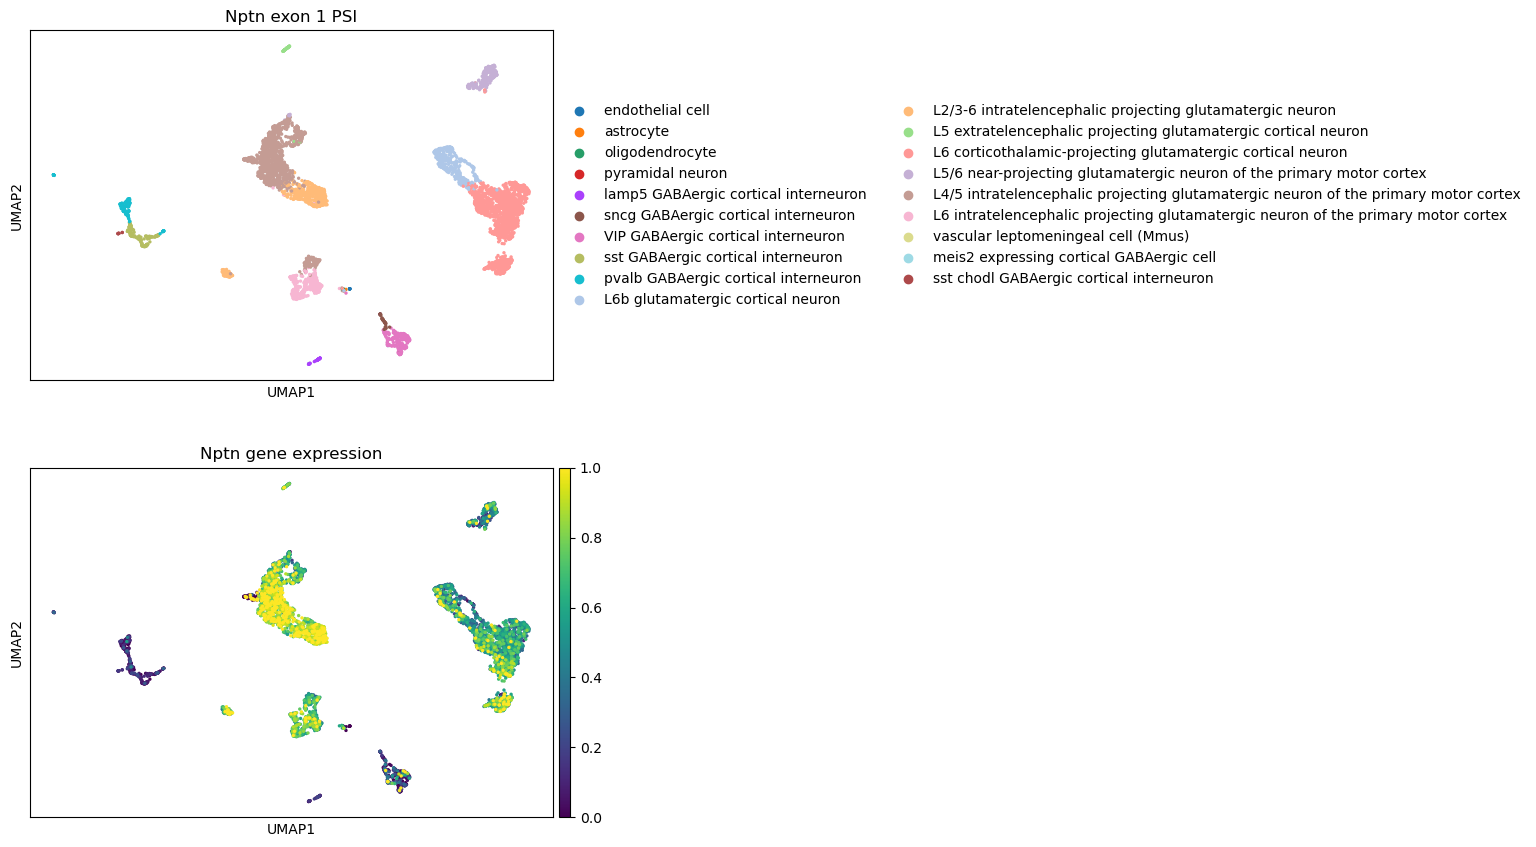

In [37]:
# Nptn (4 exons detected)
# Cors:
# Cell types: 

exon = "ENSMUSG00000032336_ProteinCoding_1"

sc.pl.umap(adata_temp, 
           color=["cell_type", exon], 
           title=['Nptn exon 1 PSI', 'Nptn gene expression'],
           ncols=1)

In [39]:
corr_df.loc[exon]

Gene                                                                                       Nptn
endothelial_cell                                                                      -0.065664
oligodendrocyte                                                                        0.056442
pvalb_GABAergic_cortical_interneuron                                                    -0.6062
L4_5_intratelencephalic_projecting_glutamatergic_neuron_of_the_primary_motor_cortex    0.749435
L5_6_near-projecting_glutamatergic_neuron_of_the_primary_motor_cortex                 -0.085273
sst_chodl_GABAergic_cortical_interneuron                                              -0.315803
L6_corticothalamic-projecting_glutamatergic_cortical_neuron                            0.740743
VIP_GABAergic_cortical_interneuron                                                    -0.218264
lamp5_GABAergic_cortical_interneuron                                                  -0.521292
sncg_GABAergic_cortical_interneuron     

### Visualize top exons by corr for a given cell type

In [ ]:
ctype = ctypes[2]
print(ctype)

In [57]:
top_exons_df = corr_df.sort_values(ctype, ascending=False)[1:10]
top_exons = top_exons_df.index.tolist()
top_genes = gene_names_df.loc[top_exons].tolist()

mask = sdata.var_names.isin(top_exons)
sdata_sub = sdata[:, mask]
psi_df = pd.DataFrame(
    sdata_sub.X, index=sdata_sub.obs_names, columns=sdata_sub.var_names
)

adata_temp = adata.copy()
adata_temp.obs = adata_temp.obs.join(psi_df)

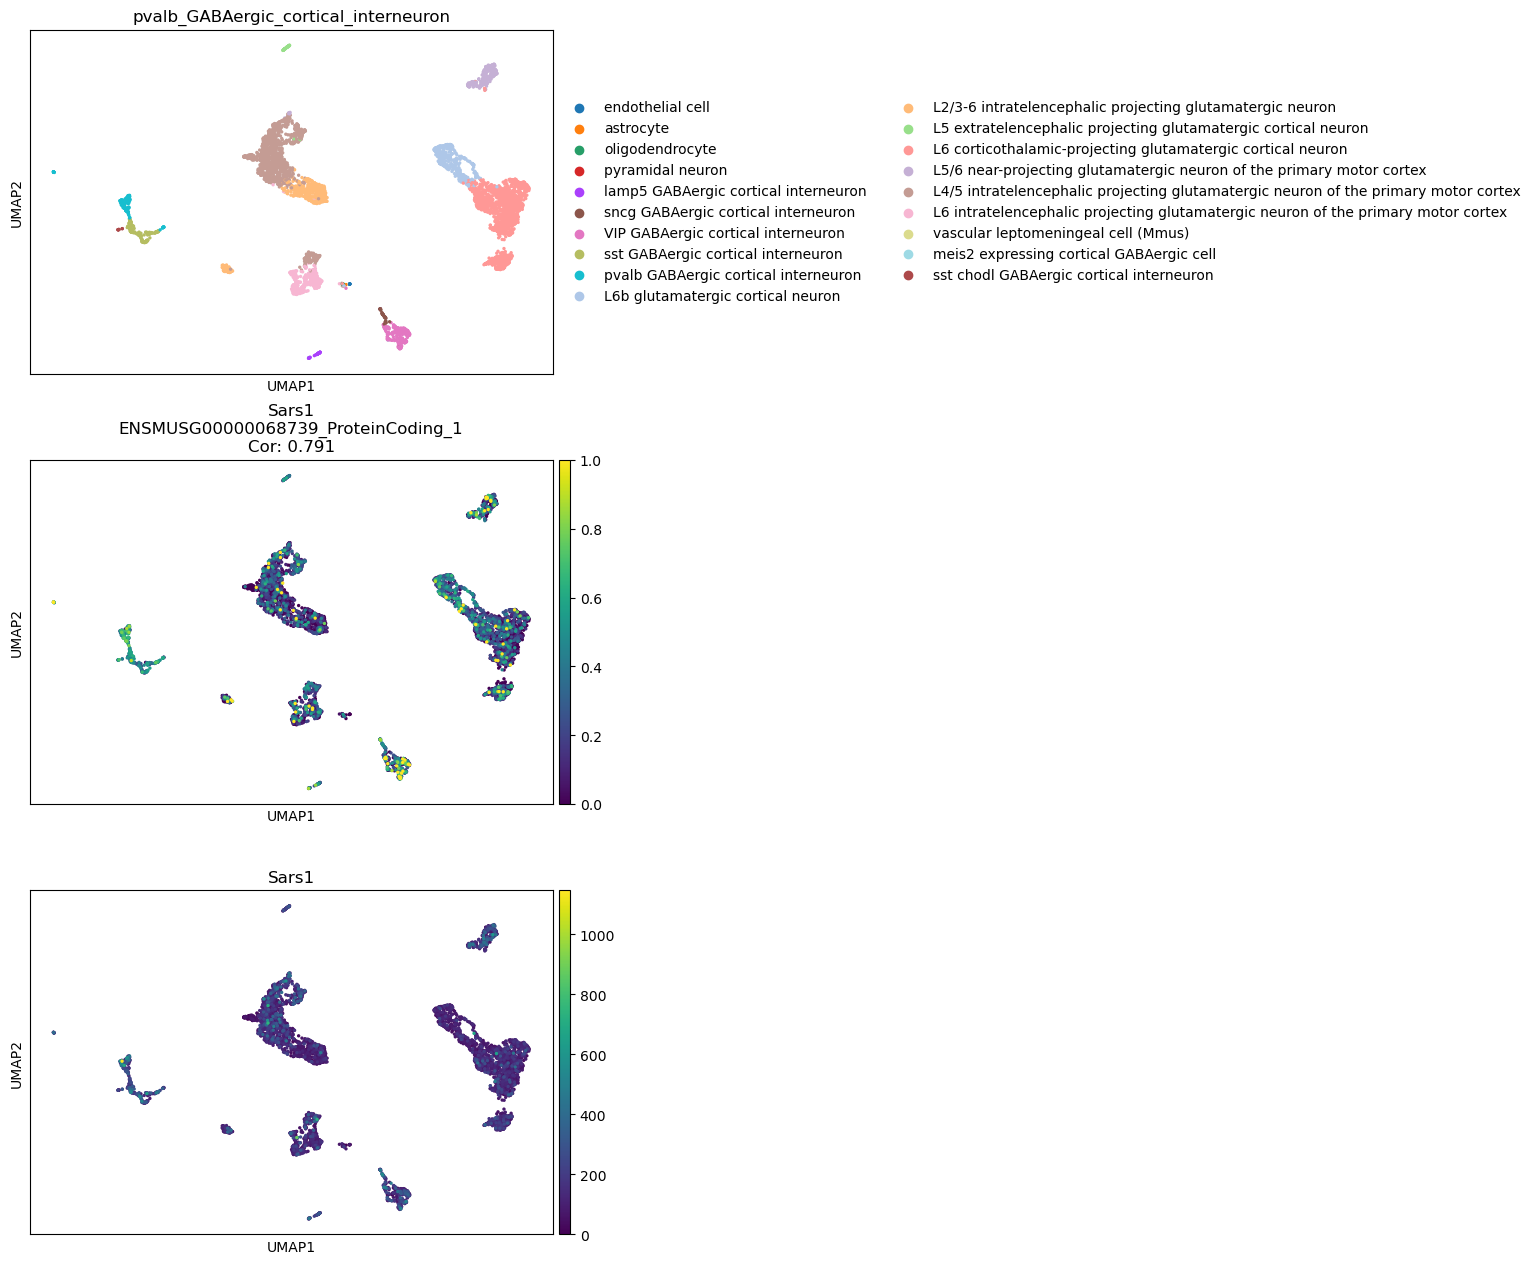

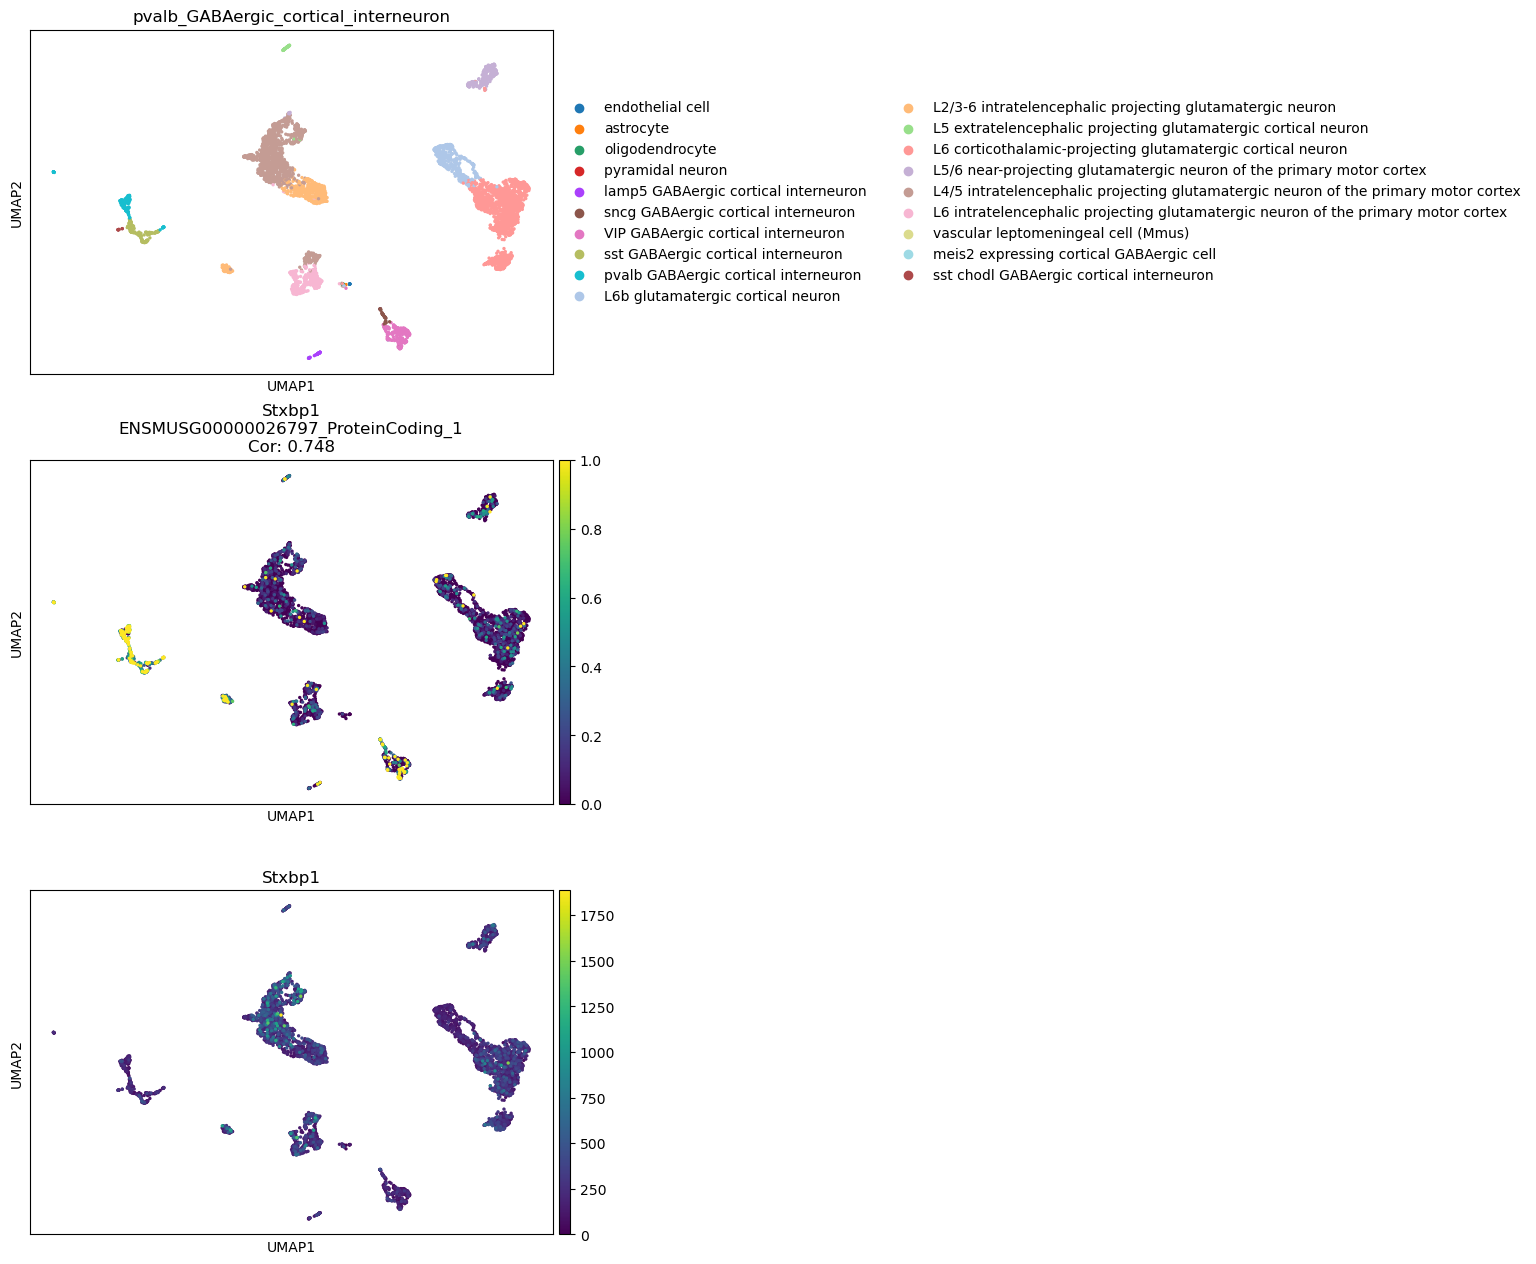

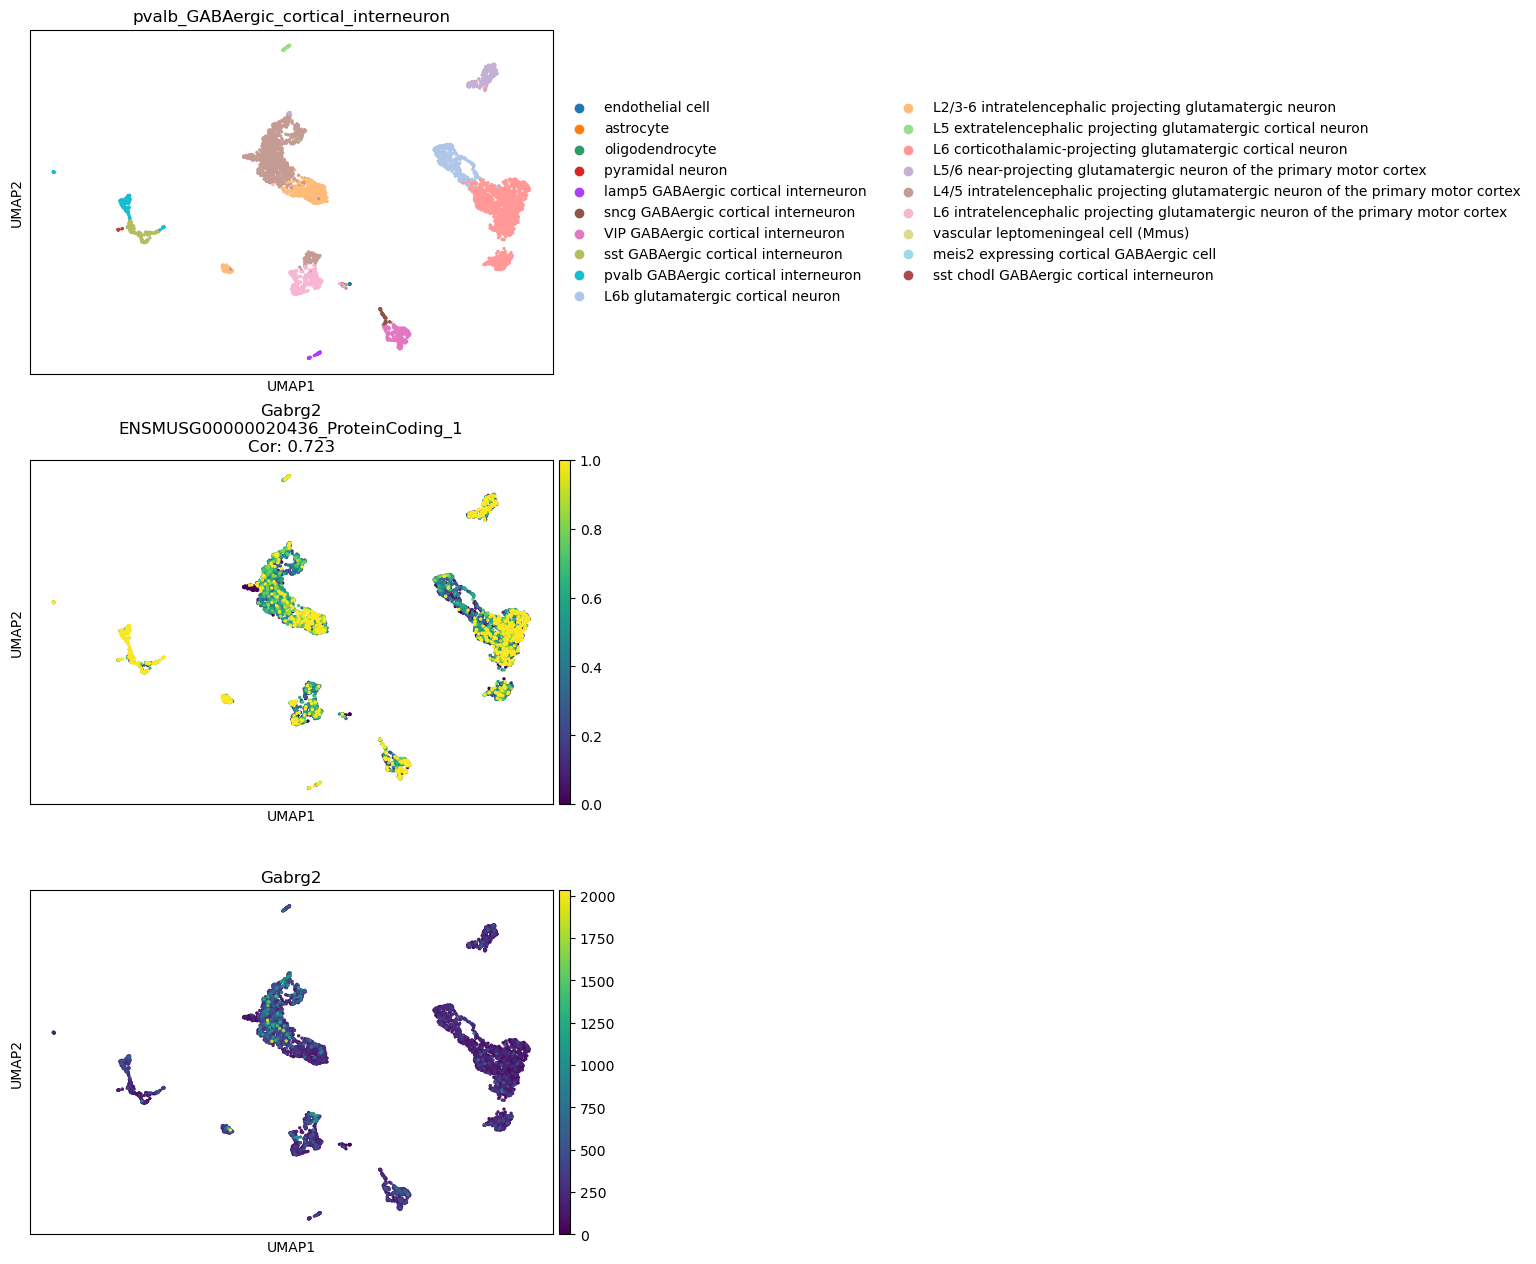

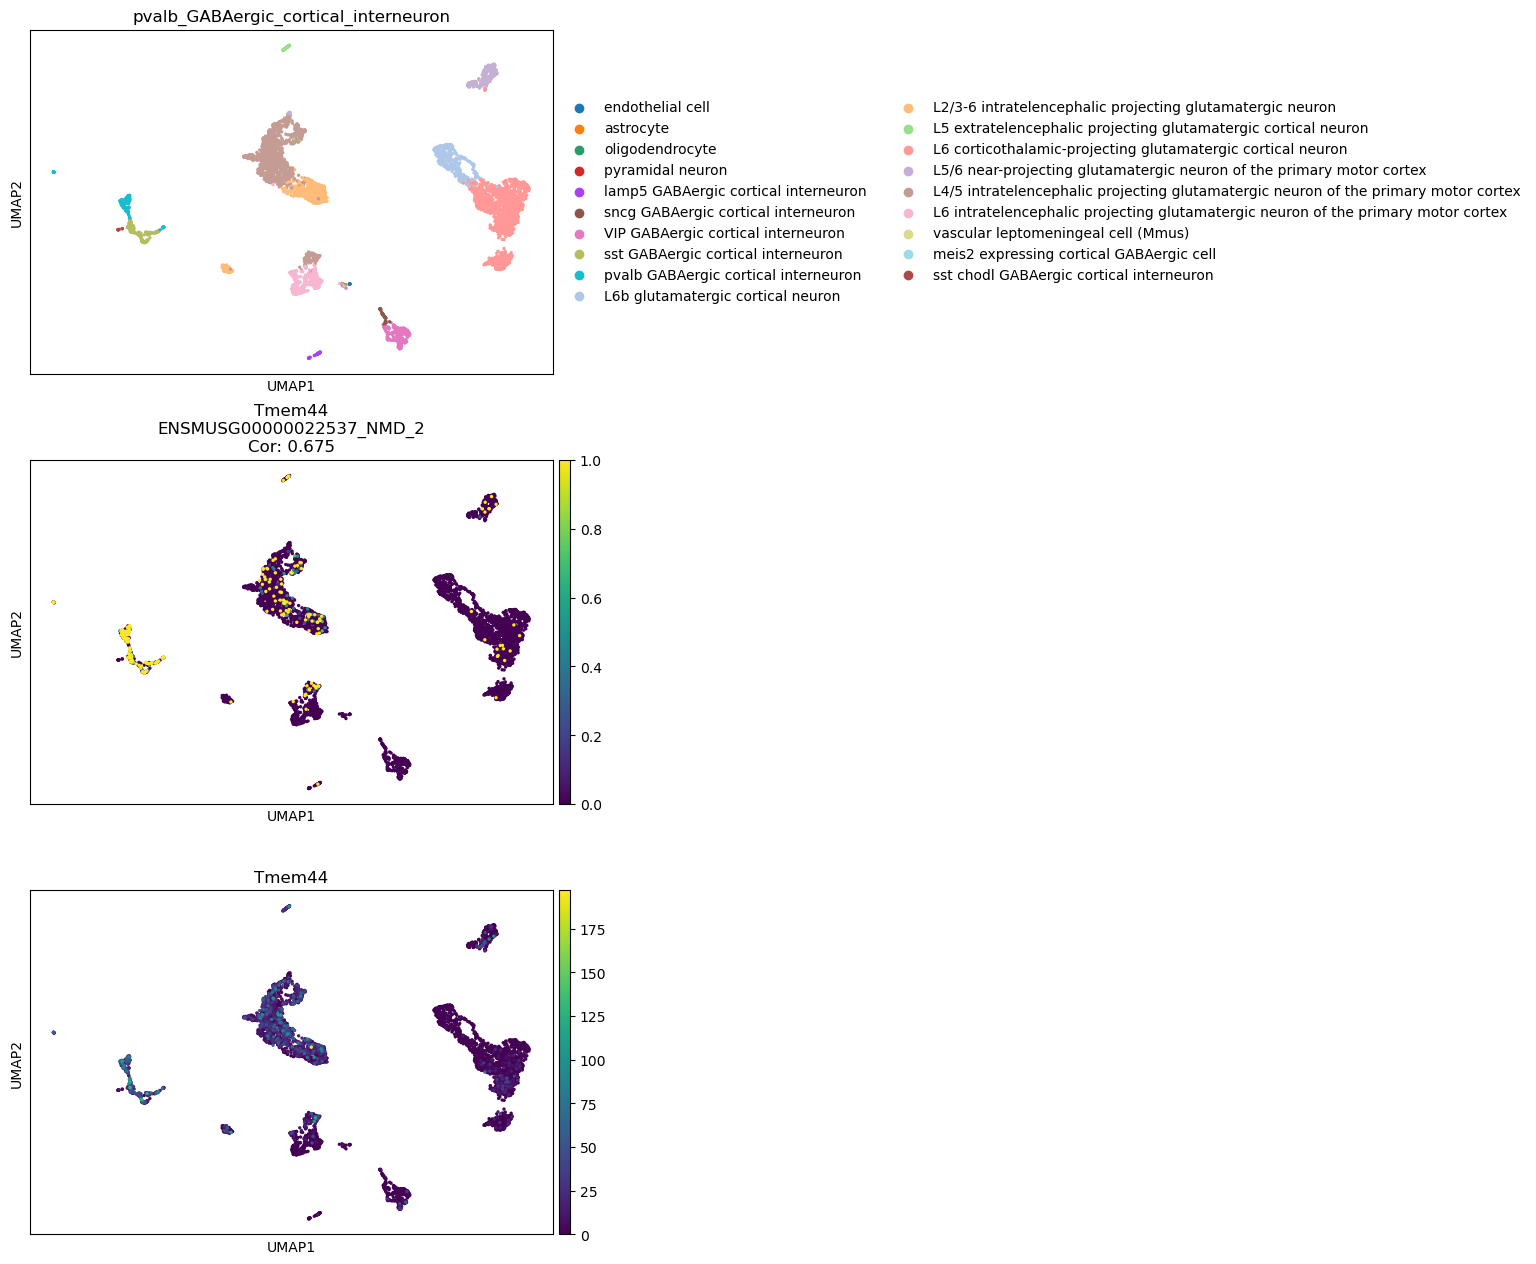

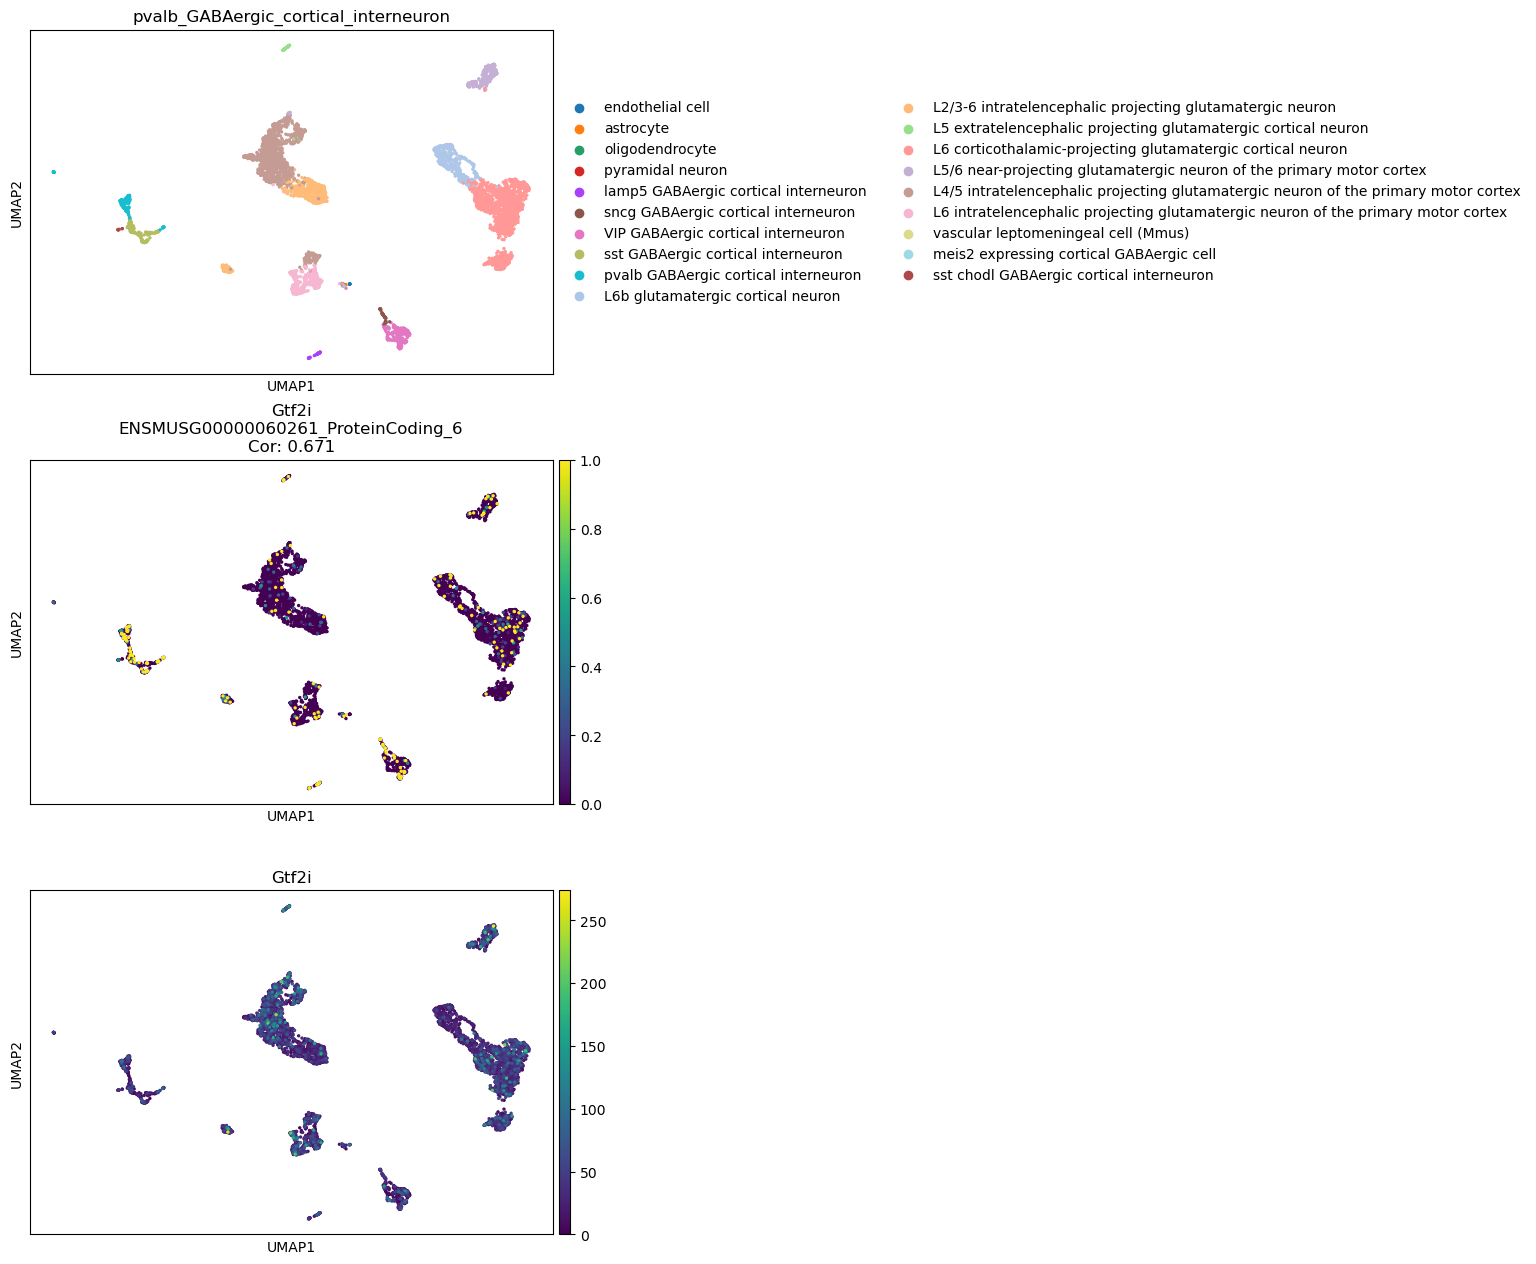

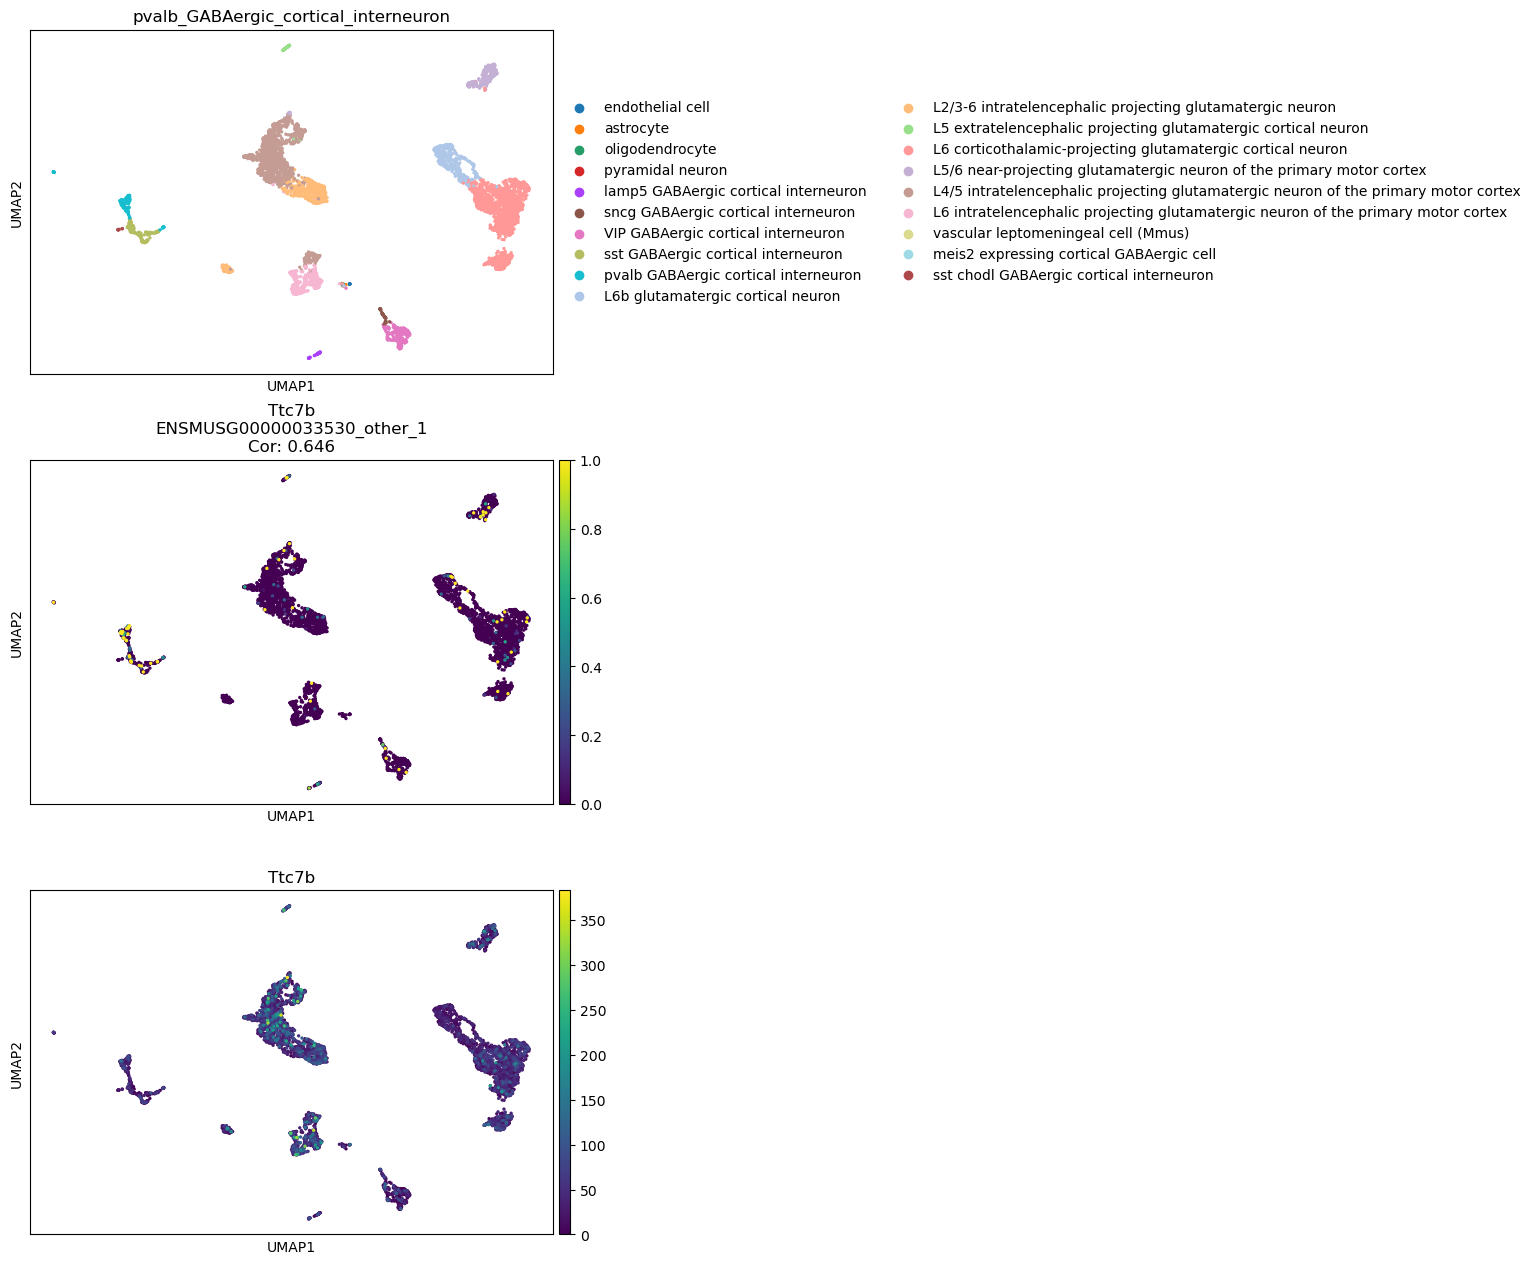

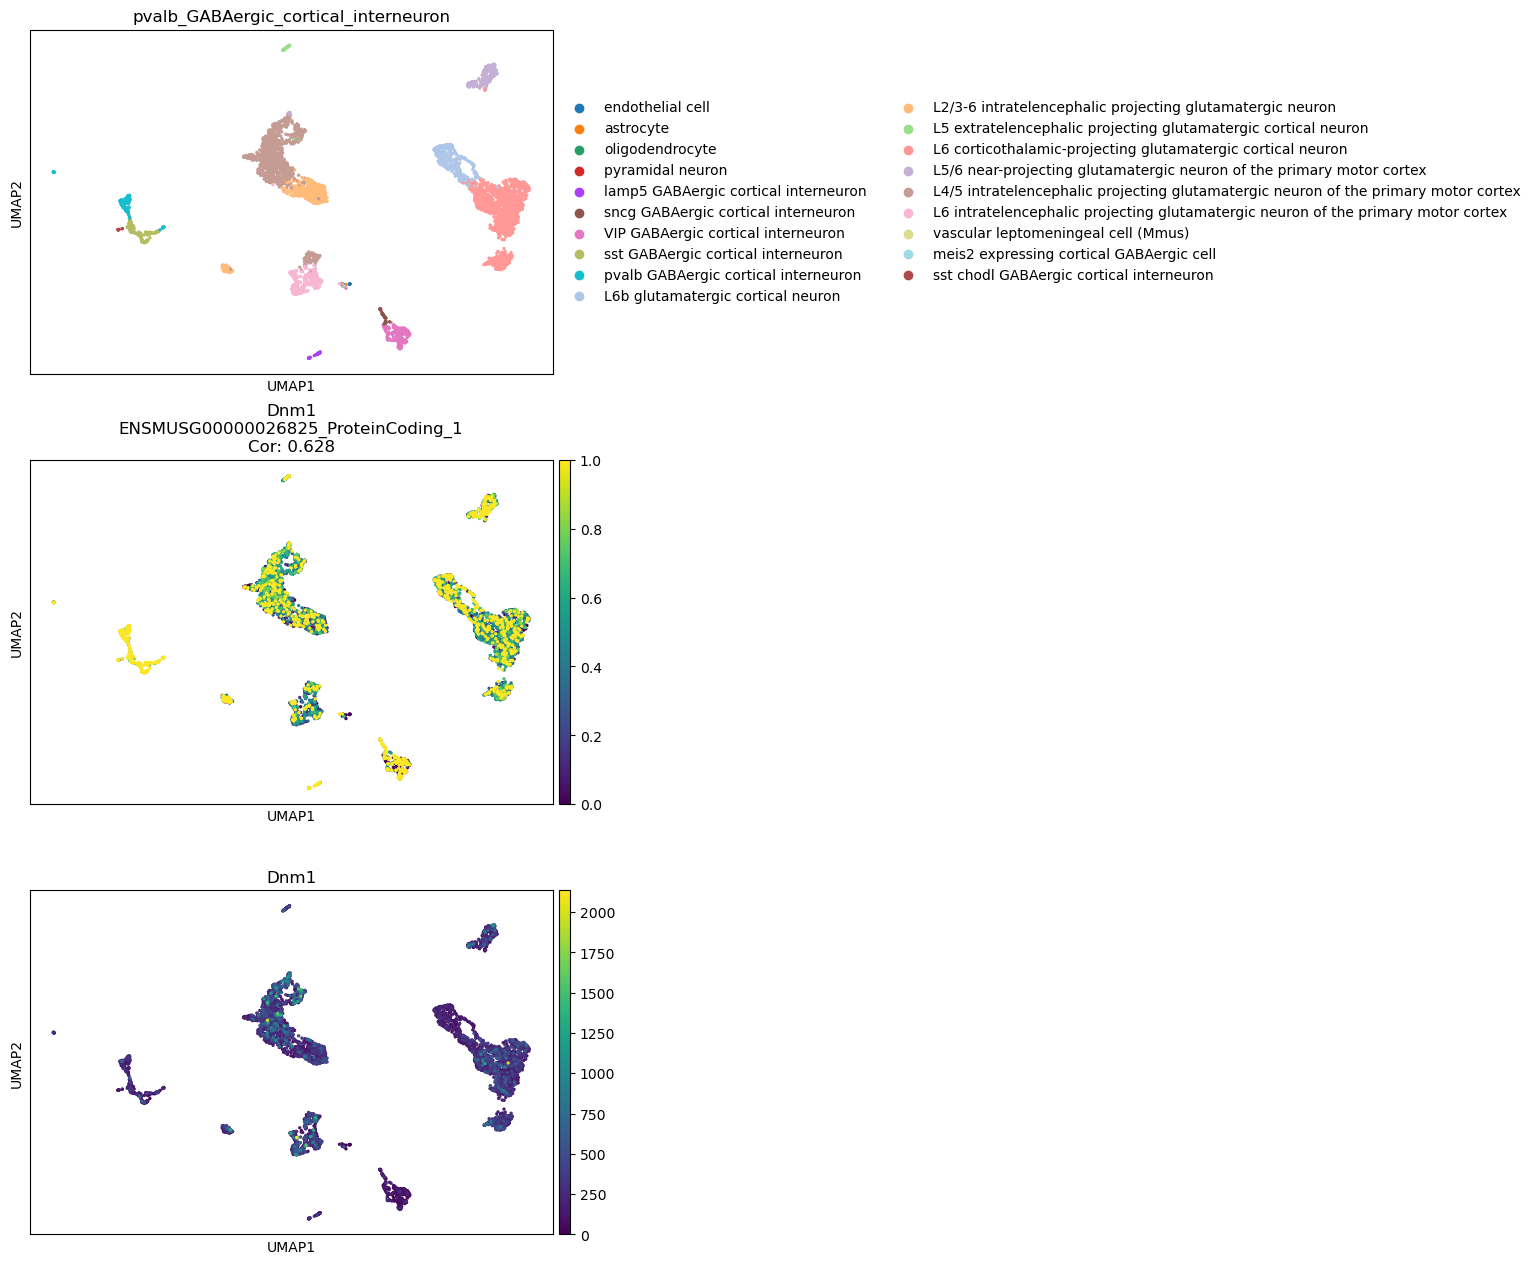

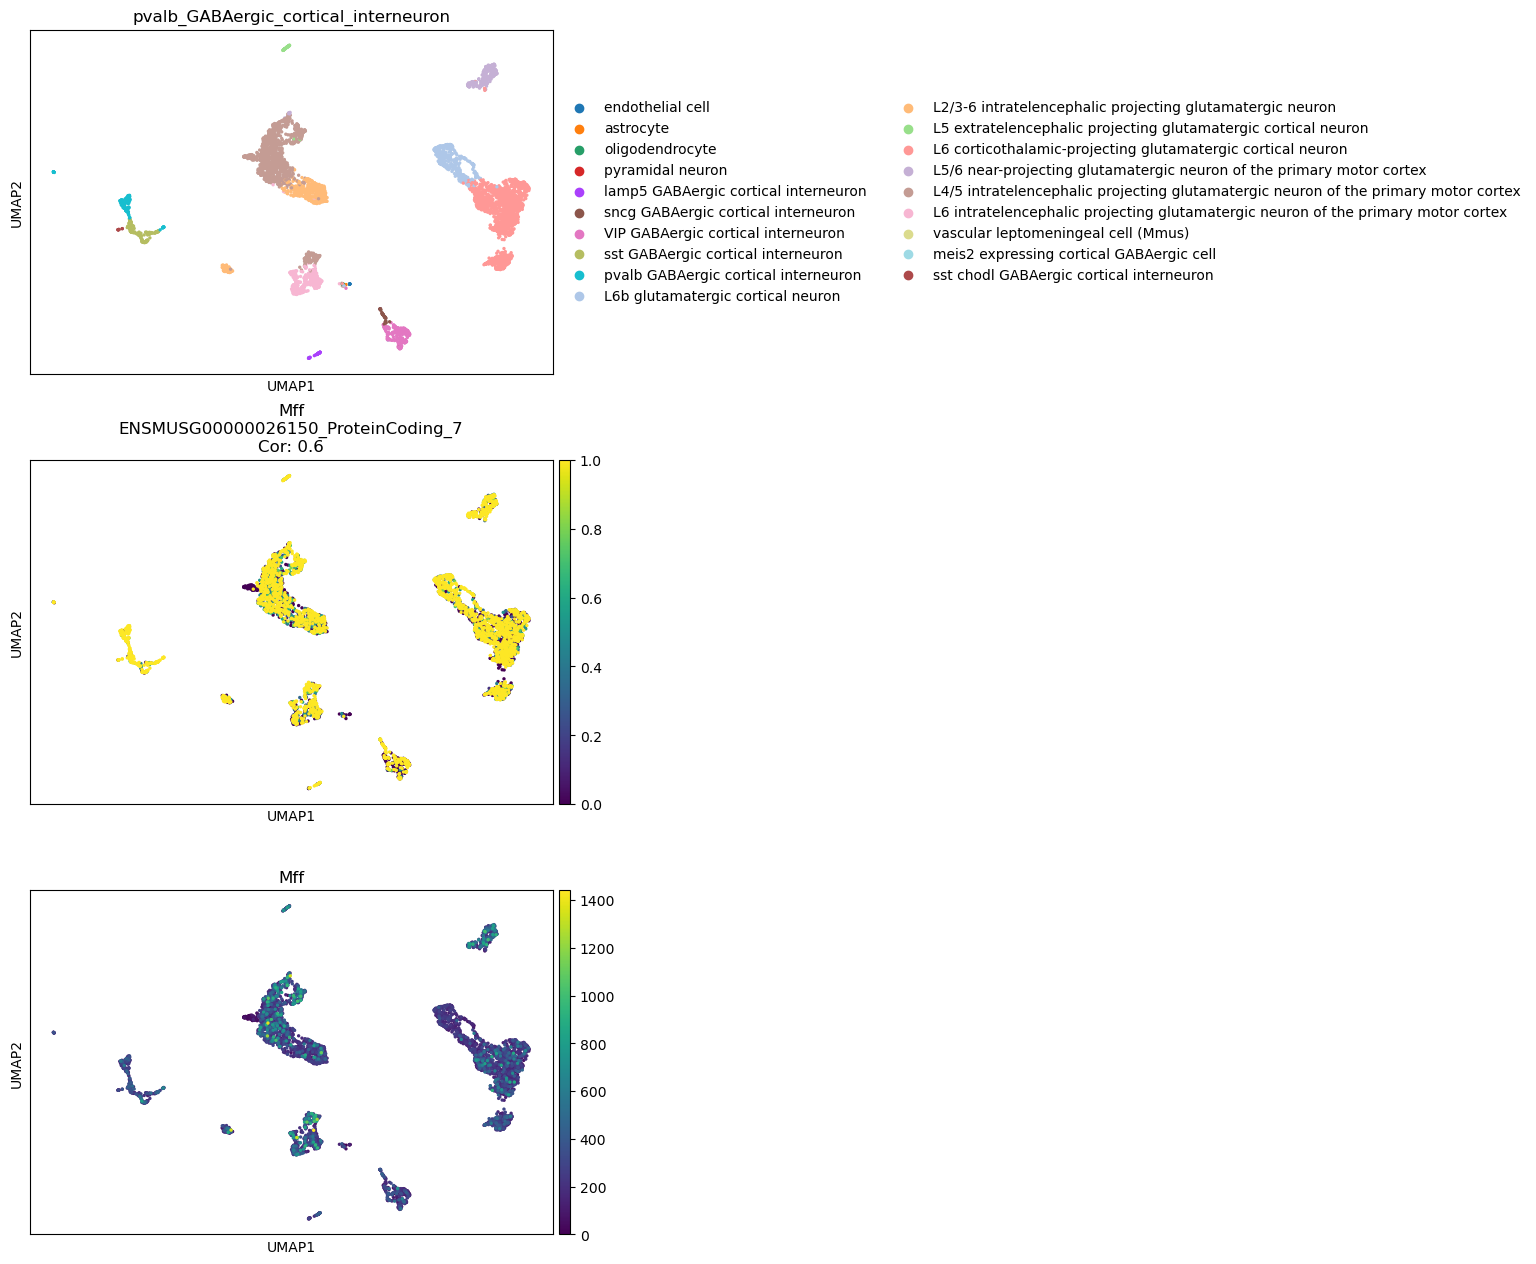

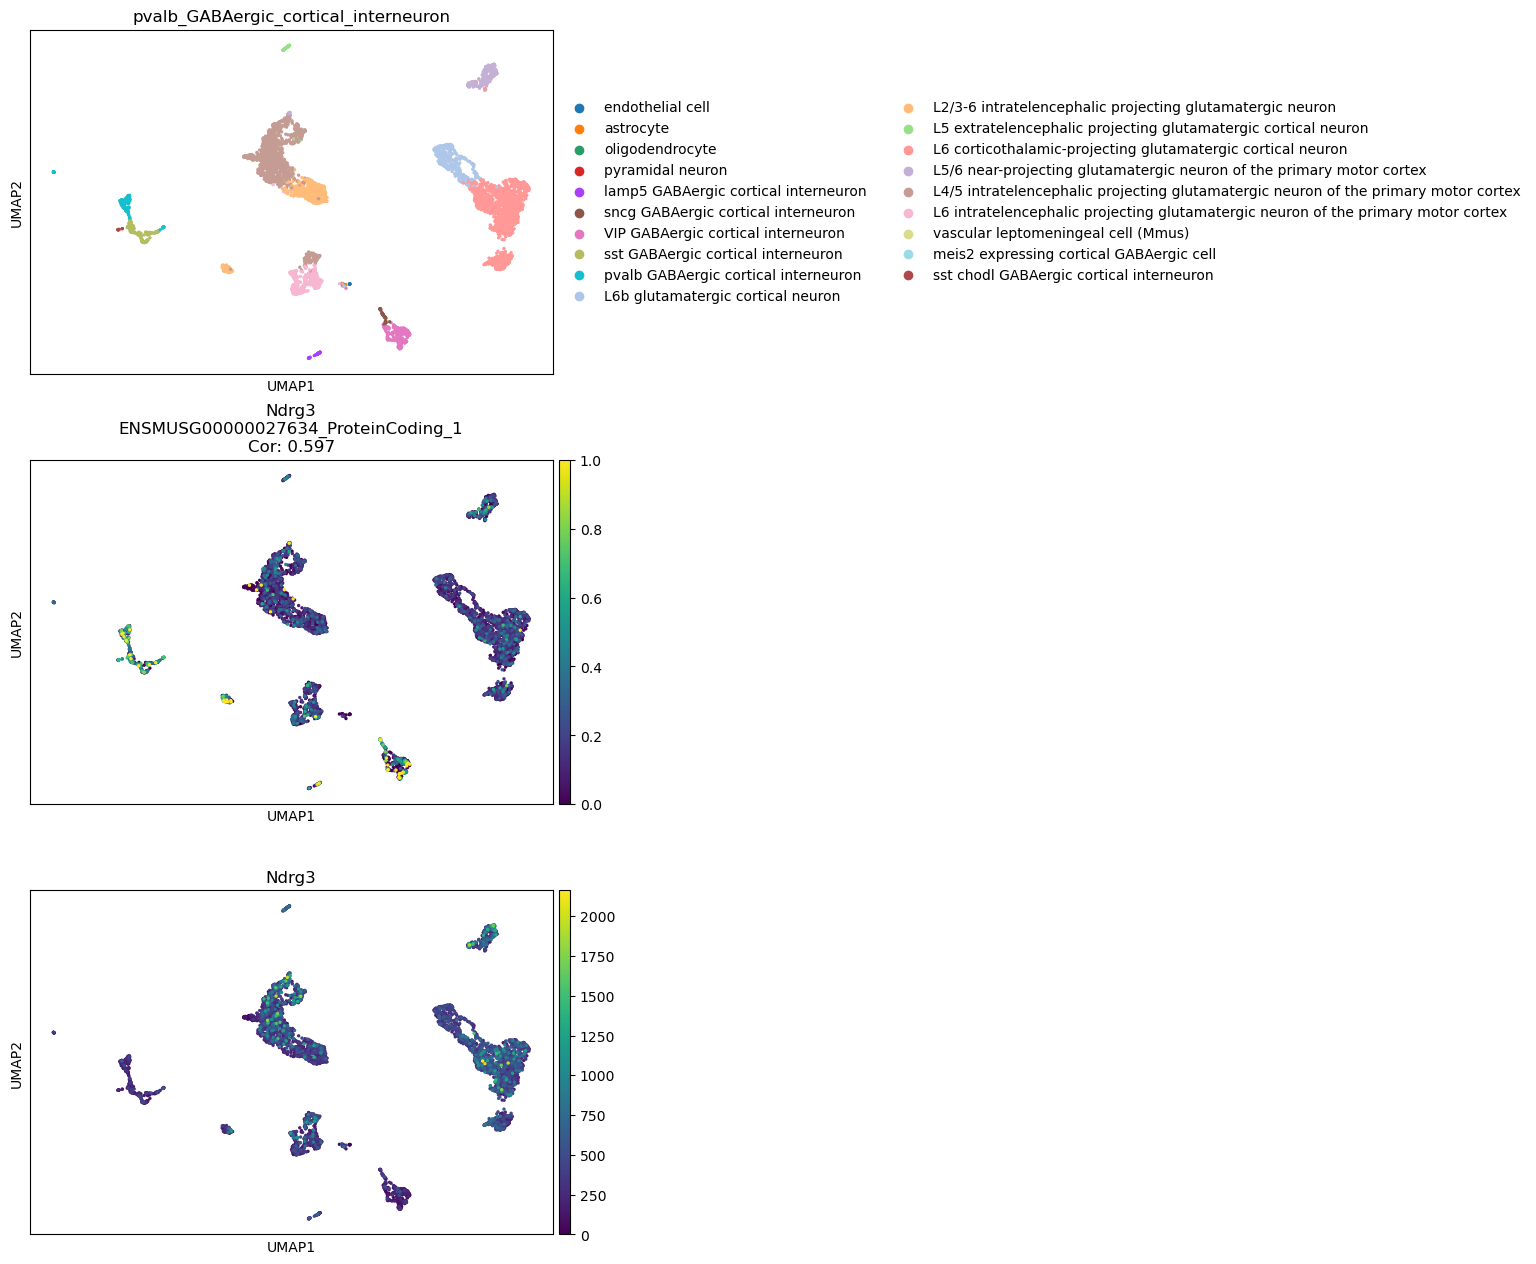

In [69]:
for idx, exon in enumerate(top_exons):
    sc.pl.umap(adata_temp, color=["cell_type", exon, top_genes[idx]], title=[ctype, f"{top_genes[idx]}\n{exon}\nCor: {np.round(corr_df.loc[exon].loc[ctype], 3)}", top_genes[idx]], ncols=1, use_raw=True)